# 05 · Checagem: a geografia inferida distorceu os resultados?

Os notebooks 02 a 04 usam o **bairro** como unidade, e o bairro de cada transação foi obtido por inferência: campo do cadastro do IPTU quando preenchido (38,8%), propagação por CEP (92,6%) e, no que sobrou, o dicionário de nomes de rua. Essa camada já produziu um erro detectado e corrigido — o caso `RUA MELO ALVES`, que mandou 255 apartamentos dos Jardins para o Jardim Monte Verde.

A pergunta deste notebook: **a inferência distorceu as conclusões?**

Com a malha do GeoSampa baixada no notebook 01, existe um caminho sem inferência nenhuma do lado do imóvel:

```
SQL do ITBI → 3 primeiros dígitos = setor fiscal → polígono → distrito
```

Os três primeiros dígitos do `SQL` **são** o código do setor fiscal do IPTU. Não é aproximação nem casamento de texto: é o mesmo identificador nos dois lados. Refazendo a análise nessa geografia e comparando com a original, dá para saber se a camada frágil mudou algum resultado.

Spoiler do que vem na seção 2: o lado do crime tem uma armadilha que quase passou batida, e resolvê-la mudou o desenho desta checagem.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy import stats

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CACHE = RAIZ / "data" / "SP" / "cache"

malha = gpd.read_file(CACHE / "distritos_sp.geojson")[["nm_distrito_municipal", "geometry"]]
setor_para_distrito = pd.read_parquet(CACHE / "setor_para_distrito.parquet")
bairros = pd.read_parquet(CACHE / "bairros.parquet")
transacoes = pd.read_parquet(CACHE / "base_modelagem.parquet",
                             columns=["setor_fiscal", "bairro", "preco_m2", "area_construida", "idade"])
crimes = pd.read_parquet(CACHE / "crimes_sp.parquet", columns=["lat", "lon", "bairro", "natureza", "ano"])
MES_REFERENCIA = (CACHE / "mes_referencia.txt").read_text(encoding="utf-8").strip()

AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SUPERFICIE, TINTA, TINTA2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
DIVERGENTE = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", "#e34948"])

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})


def reais(valor, _=None):
    return f"R$ {valor:,.0f}".replace(",", ".")


FORMATO_REAIS = FuncFormatter(reais)
print(f"{len(malha)} distritos · {len(transacoes):,} transações · {len(crimes):,} ocorrências")

96 distritos · 312,248 transações · 2,214,258 ocorrências


## 1 · Imóveis → distrito, exato

O lado fácil. Cada transação carrega o `SQL`, cujos três primeiros dígitos são o setor fiscal; o notebook 01 já resolveu `setor fiscal → distrito` por maior sobreposição de área contra a malha do GeoSampa. Basta juntar.

In [2]:
transacoes["setor_fiscal"] = transacoes["setor_fiscal"].astype(str)
transacoes = transacoes.merge(
    setor_para_distrito[["setor_fiscal", "distrito"]], on="setor_fiscal", how="left"
)

print(f"transações com distrito: {transacoes['distrito'].notna().mean():.2%}")
print(f"distritos com transação: {transacoes['distrito'].nunique()} de {len(malha)}")

transações com distrito: 100.00%
distritos com transação: 94 de 96


## 2 · Crimes → distrito, e a armadilha

O lado do crime não tem setor fiscal, mas tem **latitude e longitude** em 81% das ocorrências. O caminho óbvio seria um ponto-em-polígono direto: 1,79 milhão de pontos contra 96 polígonos, que o índice espacial do geopandas resolve em poucos segundos.

Esse caminho óbvio está errado, e a célula abaixo mostra por quê. A disponibilidade de coordenada **não é aleatória**: ela varia de 2,8% a 97,8% entre bairros, e os piores são sistematicamente os periféricos. Usar só o que está geolocalizado representaria Guaianazes por 3% das suas ocorrências e a Vila Azevedo por 97% — e como periferia e centro diferem exatamente na variável de interesse, isso enviesaria o resultado na direção da hipótese.

Há também um viés por tipo de crime: ocorrências violentas são menos geolocalizadas (79,2%) que as patrimoniais (81,4%).

count    619.0
mean      75.0
std       17.3
min        2.8
5%        36.1
50%       80.6
95%       92.5
max       97.8

5 bairros com pior geolocalização (mín. 200 ocorrências):
bairro
GUAIANAZES             2.8
AGUA FUNDA             5.3
JARDIM SAO JANUARIO    5.5
JARDIM AVENIDA         6.9
RESIDENCIAL TAIPAS     6.9


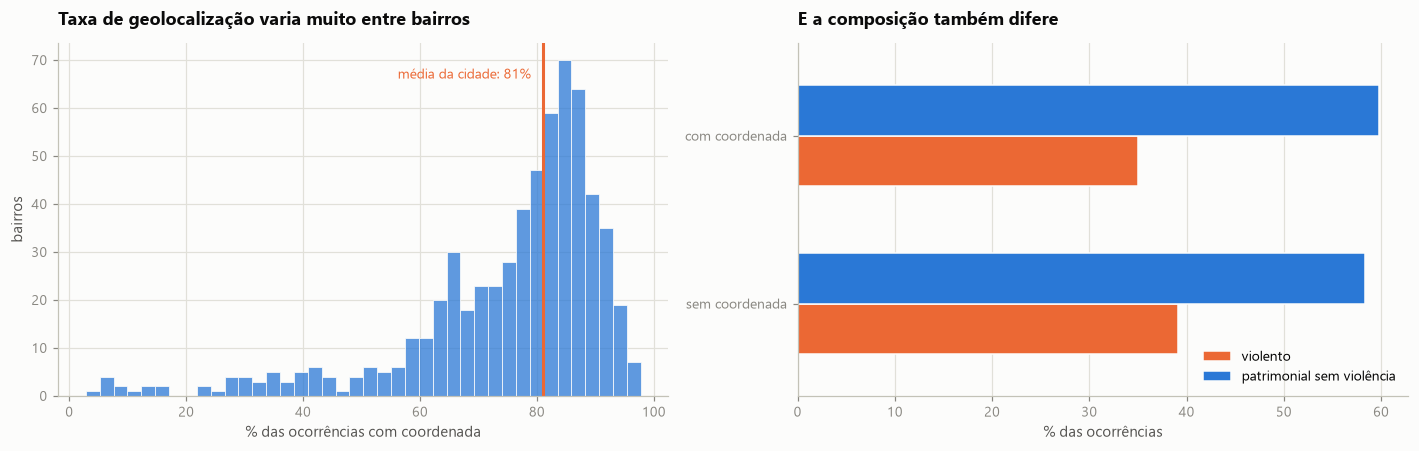

In [3]:
VIOLENTOS = ("ROUBO", "LATROCINIO", "HOMICIDIO", "LESAO CORPORAL", "ESTUPRO", "EXTORSAO", "SEQUESTRO")


def grupo_crime(natureza):
    if "ACIDENTE DE TRANSITO" in natureza or "CULPOS" in natureza:
        return "trânsito / culposo"
    if natureza.startswith("FURTO"):
        return "patrimonial sem violência"
    if any(termo in natureza for termo in VIOLENTOS):
        return "violento"
    return "outros"


crimes["grupo"] = crimes["natureza"].astype(str).map(grupo_crime)
crimes["bairro"] = crimes["bairro"].astype(str)
crimes["tem_coordenada"] = crimes["lat"].notna() & crimes["lon"].notna()

por_bairro = crimes.groupby("bairro")["tem_coordenada"].agg(["mean", "size"])
relevantes = por_bairro[por_bairro["size"] >= 200]["mean"]

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(relevantes * 100, bins=40, color=AZUL, ax=esq, edgecolor=SUPERFICIE, linewidth=0.5)
esq.axvline(crimes["tem_coordenada"].mean() * 100, color=LARANJA, linewidth=2)
esq.set(title="Taxa de geolocalização varia muito entre bairros",
        xlabel="% das ocorrências com coordenada", ylabel="bairros")
esq.annotate(f"média da cidade: {crimes['tem_coordenada'].mean():.0%}",
             (crimes["tem_coordenada"].mean() * 100, esq.get_ylim()[1] * 0.9),
             xytext=(-8, 0), textcoords="offset points", ha="right", color=LARANJA, fontsize=9)

composicao = pd.crosstab(crimes["tem_coordenada"], crimes["grupo"], normalize="index").mul(100)
composicao.index = ["sem coordenada", "com coordenada"]
composicao[["violento", "patrimonial sem violência"]].plot.barh(
    ax=drt, color=[LARANJA, AZUL], width=0.6, edgecolor=SUPERFICIE
)
drt.set(title="E a composição também difere", xlabel="% das ocorrências", ylabel="")
drt.grid(axis="y", visible=False)
drt.legend(loc="lower right", fontsize=9)

plt.tight_layout()

print(relevantes.mul(100).describe(percentiles=[0.05, 0.5, 0.95]).round(1).to_string())
print("\n5 bairros com pior geolocalização (mín. 200 ocorrências):")
print(relevantes.nsmallest(5).mul(100).round(1).to_string())

### A correção: coordenada para *mapear*, nome para *contar*

A saída separa duas tarefas que o caminho ingênuo confunde:

| tarefa | o que exige | fonte |
|---|---|---|
| descobrir **em que distrito** um bairro fica | poucos pontos bastam | coordenadas (ponto-em-polígono) |
| **contar** quantas ocorrências aquele bairro teve | todas as ocorrências | nome do bairro (99,7% preenchido) |

Guaianazes tem só 2,8% das ocorrências geolocalizadas, mas isso ainda são 64 pontos — mais que suficiente para estabelecer que ela fica no distrito de Guaianases. Estabelecido o distrito, contam-se **todas** as ocorrências do bairro, geolocalizadas ou não.

Com esse desenho a cobertura sobe de 81% para **99,2%** dos crimes, mantendo a geografia exata. É a diferença entre usar a coordenada como amostra (enviesada) e usá-la como chave (não enviesada).

Exige-se um mínimo de 20 pontos por bairro, e a **pureza** do mapeamento é reportada — nomes de bairro não respeitam divisa de distrito, então alguns ficam divididos.

In [4]:
MINIMO_PONTOS = 20

geolocalizados = crimes[crimes["tem_coordenada"]]
pontos = gpd.GeoDataFrame(
    geolocalizados[["bairro"]],
    geometry=gpd.points_from_xy(geolocalizados["lon"], geolocalizados["lat"]),
    crs=4326,
)
dentro = gpd.sjoin(pontos, malha, how="inner", predicate="within")

pares = dentro.groupby(["bairro", "nm_distrito_municipal"]).size().rename("n").reset_index()
bairro_para_distrito = (
    pares.sort_values("n")
    .groupby("bairro")
    .agg(distrito=("nm_distrito_municipal", "last"), pontos_no_modal=("n", "last"), pontos=("n", "sum"))
)
bairro_para_distrito["pureza"] = (
    bairro_para_distrito["pontos_no_modal"] / bairro_para_distrito["pontos"]
)
bairro_para_distrito = bairro_para_distrito[bairro_para_distrito["pontos"] >= MINIMO_PONTOS]

crimes["distrito"] = crimes["bairro"].map(bairro_para_distrito["distrito"])
peso = crimes["bairro"].map(bairro_para_distrito["pureza"])

print(f"bairros mapeados: {len(bairro_para_distrito):,}")
print(f"crimes com distrito: {crimes['distrito'].notna().mean():.2%}")
print(f"   (seria {crimes['tem_coordenada'].mean():.1%} pelo caminho ingênuo)")
print(f"distritos alcançados: {crimes['distrito'].nunique()} de {len(malha)}")
print(f"pureza média do mapeamento, ponderada por ocorrência: {peso.mean():.1%}")

bairros mapeados: 1,453
crimes com distrito: 99.23%
   (seria 81.0% pelo caminho ingênuo)
distritos alcançados: 96 de 96
pureza média do mapeamento, ponderada por ocorrência: 90.4%


## 3 · Agregação por distrito

As mesmas quatro medidas de crime do notebook 02, agora no nível distrito. A definição de `grupo_crime` é idêntica — se fosse diferente, a comparação mediria a mudança de definição, não a mudança de geografia.

In [5]:
ANOS_COMPLETOS = [2022, 2023, 2024, 2025]

crime_distrito = (
    crimes[crimes["ano"].isin(ANOS_COMPLETOS) & crimes["distrito"].notna()]
    .groupby(["distrito", "grupo"])
    .size()
    .unstack(fill_value=0)
    .div(len(ANOS_COMPLETOS))
)

preco_distrito = transacoes.dropna(subset=["distrito"]).groupby("distrito").agg(
    preco_m2_mediano=("preco_m2", "median"),
    n_transacoes=("preco_m2", "size"),
    area_mediana=("area_construida", "median"),
    idade_mediana=("idade", "median"),
)

distritos = preco_distrito.join(crime_distrito, how="inner")
distritos["crimes_total"] = distritos[crime_distrito.columns].sum(axis=1)
distritos["violentos"] = distritos["violento"]
distritos["share_violento"] = distritos["violentos"] / distritos["crimes_total"]
distritos["violentos_por_1k"] = distritos["violentos"] / distritos["n_transacoes"] * 1000

distritos = distritos[distritos["n_transacoes"].ge(30) & distritos["crimes_total"].ge(30)]
for coluna in ["crimes_total", "violentos", "violentos_por_1k"]:
    distritos[f"log_{coluna}"] = np.log10(1 + distritos[coluna])

print(f"{len(distritos)} distritos aprovados, cobrindo {distritos['n_transacoes'].sum():,} transações")
distritos.sort_values("preco_m2_mediano", ascending=False).head(6)[
    ["preco_m2_mediano", "n_transacoes", "crimes_total", "violentos", "share_violento"]
].round(2)

93 distritos aprovados, cobrindo 312,247 transações


,preco_m2_mediano,n_transacoes,crimes_total,violentos,share_violento
distrito,,,,,
JARDIM PAULISTA,8878.57,6803,7409.50,1786.75,0.24
PINHEIROS,8810.38,3662,12279.25,3343.75,0.27
MOEMA,8344.94,8991,4721.00,1332.25,0.28
ITAIM BIBI,8306.67,12586,10372.00,3225.25,0.31
ALTO DE PINHEIROS,8216.96,4238,1651.75,520.75,0.32
CONSOLACAO,7170.96,7576,10538.25,2784.00,0.26


## 4 · A comparação

Lado a lado, as mesmas quatro correlações nas duas geografias. O que se quer ver: **mesmo sinal e magnitude parecida**. Se a inferência tivesse inventado o resultado, ele desapareceria na geografia exata.

In [6]:
MEDIDAS = {
    "crimes totais / ano (log)": "log_crimes_total",
    "crimes violentos / ano (log)": "log_violentos",
    "% de crimes que são violentos": "share_violento",
    "violentos por mil transações (log)": "log_violentos_por_1k",
}

GEOGRAFIAS = {
    "bairro (inferido)": bairros,
    "distrito (exato)": distritos,
}


def correlacoes(dados, coluna):
    pearson = stats.pearsonr(dados[coluna], dados["preco_m2_mediano"])
    spearman = stats.spearmanr(dados[coluna], dados["preco_m2_mediano"])
    return {"Pearson r": pearson.statistic, "Spearman ρ": spearman.statistic,
            "p (Spearman)": spearman.pvalue, "unidades": len(dados)}


comparacao = pd.DataFrame(
    [
        {"medida de crime": medida, "geografia": nome, **correlacoes(dados, coluna)}
        for medida, coluna in MEDIDAS.items()
        for nome, dados in GEOGRAFIAS.items()
    ]
).set_index(["medida de crime", "geografia"])

comparacao.style.format({
    "Pearson r": "{:+.3f}", "Spearman ρ": "{:+.3f}", "p (Spearman)": "{:.1e}",
}).background_gradient(cmap=DIVERGENTE, vmin=-0.7, vmax=0.7, subset=["Pearson r", "Spearman ρ"])

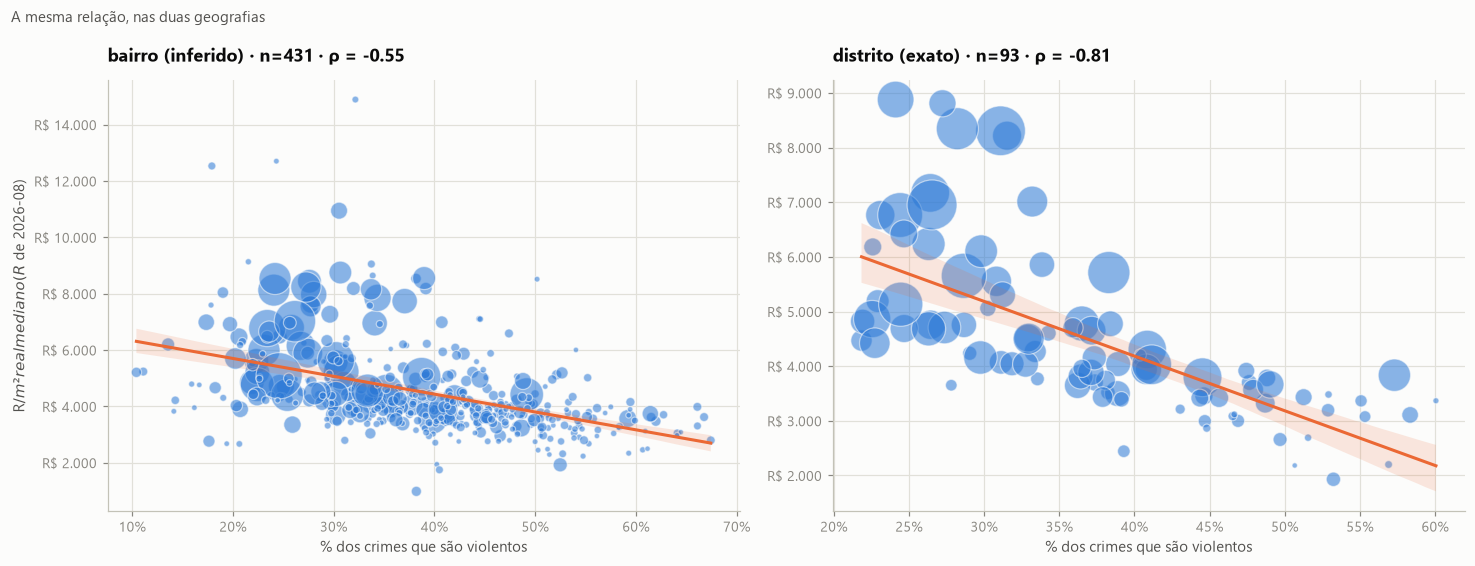

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 5.2))

for eixo, (nome, dados) in zip(eixos, GEOGRAFIAS.items()):
    sns.regplot(
        data=dados, x="share_violento", y="preco_m2_mediano", ax=eixo,
        scatter_kws={"s": dados["n_transacoes"] / 12 + 10, "alpha": 0.55, "color": AZUL,
                     "linewidths": 0.8, "edgecolor": SUPERFICIE},
        line_kws={"color": LARANJA, "linewidth": 2},
    )
    rho = stats.spearmanr(dados["share_violento"], dados["preco_m2_mediano"]).statistic
    eixo.set(title=f"{nome} · n={len(dados)} · ρ = {rho:+.2f}",
             xlabel="% dos crimes que são violentos", ylabel="")
    eixo.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    eixo.yaxis.set_major_formatter(FORMATO_REAIS)

eixos[0].set_ylabel(f"R$/m² real mediano (R$ de {MES_REFERENCIA})")
fig.suptitle("A mesma relação, nas duas geografias", x=0.01, ha="left", color=TINTA2, fontsize=10)
plt.tight_layout()

## 5 · O teste formal nas duas geografias

A regressão da seção 8 do notebook 03, repetida nas duas unidades e com os mesmos controles.

In [8]:
FORMULA = (
    "np.log(preco_m2_mediano) ~ log_violentos + share_violento"
    " + np.log(area_mediana) + idade_mediana + np.log(n_transacoes)"
)

ajustes = {nome: smf.ols(FORMULA, data=dados).fit() for nome, dados in GEOGRAFIAS.items()}

resumo = pd.DataFrame(
    [
        {
            "geografia": nome,
            "unidades": int(ajuste.nobs),
            "R²": ajuste.rsquared,
            "coef. share_violento": ajuste.params["share_violento"],
            "IC 2,5%": ajuste.conf_int().loc["share_violento", 0],
            "IC 97,5%": ajuste.conf_int().loc["share_violento", 1],
            "p-valor": ajuste.pvalues["share_violento"],
            "efeito de +10 p.p.": np.exp(ajuste.params["share_violento"] * 0.10) - 1,
        }
        for nome, ajuste in ajustes.items()
    ]
).set_index("geografia")

resumo.style.format({
    "R²": "{:.3f}", "coef. share_violento": "{:+.3f}", "IC 2,5%": "{:+.3f}",
    "IC 97,5%": "{:+.3f}", "p-valor": "{:.1e}", "efeito de +10 p.p.": "{:+.1%}",
}).set_caption("Coeficiente da composição criminal nas duas geografias")

,unidades,R²,coef. share_violento,"IC 2,5%","IC 97,5%",p-valor,efeito de +10 p.p.
geografia,,,,,,,
bairro (inferido),431,0.416,-0.922,-1.138,-0.706,6.7e-16,-8.8%
distrito (exato),93,0.750,-1.816,-2.276,-1.355,1.1e-11,-16.6%


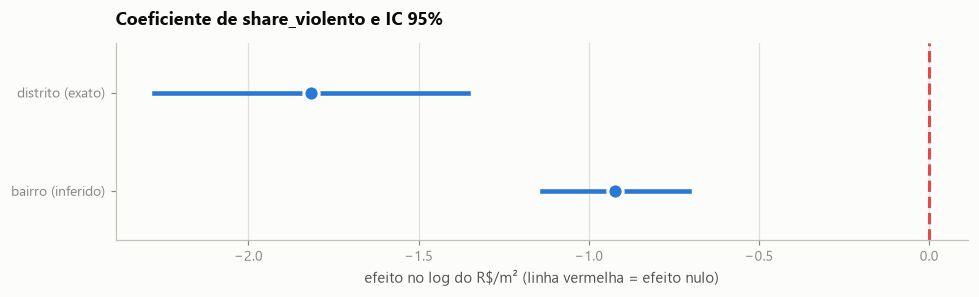

In [9]:
fig, eixo = plt.subplots(figsize=(9, 2.8))

for altura, (nome, ajuste) in enumerate(ajustes.items()):
    baixo, alto = ajuste.conf_int().loc["share_violento"]
    eixo.plot([baixo, alto], [altura, altura], color=AZUL, linewidth=3)
    eixo.plot(ajuste.params["share_violento"], altura, "o", color=AZUL, markersize=10,
              markeredgecolor=SUPERFICIE, markeredgewidth=2)

eixo.axvline(0, color="#e34948", linewidth=2, linestyle="--")
eixo.set(yticks=range(len(ajustes)), yticklabels=list(ajustes),
         title="Coeficiente de share_violento e IC 95%",
         xlabel="efeito no log do R$/m² (linha vermelha = efeito nulo)")
eixo.grid(axis="y", visible=False)
eixo.margins(y=0.5)
plt.tight_layout()

## 6 · Veredito

### A inferência não inventou nada

Os quatro sinais são preservados, e o padrão é o mesmo nas duas geografias:

| medida de crime | bairro (inferido, n=430) | distrito (exato, n=93) |
|---|---|---|
| crimes totais / ano | ρ = +0,146 | ρ = **+0,376** |
| crimes violentos / ano | ρ = +0,036 | ρ = −0,002 |
| **% de crimes violentos** | ρ = **−0,548** | ρ = **−0,813** |
| violentos por mil transações | ρ = −0,296 | ρ = **−0,703** |

A conclusão central sobrevive intacta: **contagem de crime não prevê preço — se algo, prevê preço mais alto. Composição prevê, e forte.** Se a camada de nome de rua e CEP tivesse fabricado o resultado, ele teria desaparecido aqui. Não desapareceu.

### Mas não leia os números do distrito como "os verdadeiros"

Na geografia exata tudo fica mais forte: ρ de −0,548 para −0,813, R² de 0,411 para 0,750, coeficiente de −0,912 para −1,815 (de −8,7% para −16,6% por cada 10 pontos percentuais de violência). É tentador concluir que esse é o efeito real e que o bairro o subestimava. **Dois motivos diferentes produzem esse aumento, e só um deles é mérito:**

1. **Menos erro de atribuição** — mérito real. Cada transação mal etiquetada atenua a correlação, e remover a inferência recupera sinal genuíno.
2. **Agregação** — artefato. 93 distritos com ~3.400 transações cada têm medianas muito mais estáveis que 430 bairros com ~730. Agregar **sempre** eleva coeficiente de correlação, independentemente de haver melhora na medição. É o efeito ecológico clássico: comparar ρ entre níveis de agregação diferentes é comparar coisas distintas.

Como os dois empurram na mesma direção, não é possível separá-los com os dados disponíveis. A leitura defensável:

- **Os sinais e a ordenação das quatro medidas são comparáveis** e idênticos — é isso que valida a análise original.
- **As magnitudes não são comparáveis** entre os níveis. O −8,7% do bairro é provavelmente atenuado; o −16,6% do distrito é provavelmente inflado pela agregação. O efeito real está em algum lugar entre os dois, e não dá para dizer mais perto de qual.

### O que mais ficou mais nítido

A relação **positiva** entre volume de crime e preço fica mais evidente no distrito (ρ de +0,15 para +0,38). Pinheiros registra 12.279 ocorrências por ano e custa R$ 8.810/m²; Itaim Bibi, 10.372 e R$ 8.307. São os distritos de maior circulação de pessoas da cidade. Isso reforça, e não enfraquece, a distinção entre **exposição** e **risco** que organiza todo o projeto.

### A armadilha da seção 2, que valeu o notebook inteiro

O desenho natural desta checagem seria atribuir cada crime ao distrito por ponto-em-polígono sobre a sua coordenada. Esse desenho está errado, e de um jeito que confirmaria a hipótese por motivo falso: a taxa de geolocalização varia de **2,8% a 97,8%** entre bairros, e os piores são sistematicamente periféricos. Guaianazes seria representada por 3% das suas ocorrências, a Vila Azevedo por 97% — e periferia e centro diferem exatamente na variável de interesse.

A correção foi separar duas tarefas que o caminho ingênuo mistura: a coordenada serve para **descobrir** em que distrito o bairro fica (bastam 20 pontos), e o nome do bairro serve para **contar** as ocorrências (99,7% preenchido). Resultado: 99,23% de cobertura em vez de 81%, sem viés regional.

Essa é a lição metodológica mais transferível do projeto: **dado faltante raramente falta ao acaso**, e usar o subconjunto completo como se fosse amostra aleatória é o erro mais fácil de cometer e mais difícil de notar.

### Limitações desta checagem

- **A pureza do mapeamento é 90,4%**, não 100%. Nomes de bairro não respeitam divisa de distrito — "Guaianazes" tem pureza de 51,6%, espalhada entre Guaianases e Lajeado. Cerca de 10% das ocorrências estão contadas no distrito vizinho ao correto.
- **O lado do imóvel é exato, o lado do crime não.** `SQL → setor fiscal → distrito` não tem inferência alguma; o crime ainda depende do nome do bairro para ser contado.
- **`setor fiscal → distrito` usa maior sobreposição de área**, não a localização exata do lote. Um setor fiscal que cruza a divisa de distrito tem todas as suas transações atribuídas ao distrito dominante.
- **93 distritos é pouco para o modelo hedônico.** Esta checagem compara correlação e OLS agregado, não o modelo de 312 mil transações do notebook 03 — aquele continua valendo no nível da transação, onde o bairro entra apenas como fonte das variáveis de crime.